In [ ]:
# Loading core libraries and plot configs
import numpy as np
import math
from datascience import *

# These lines set up the plotting functionality and formatting
import matplotlib
import matplotlib.pyplot as plots
%matplotlib inline
plots.style.use('fivethirtyeight')
import warnings
warnings.simplefilter(action="ignore", category=FutureWarning)

# Evaluating Healthcare Innovation Investments and Their Expected Impact
Name: Sue Kabba

## Dataset Description
This project uses the Innovation Center Model Awardees dataset published by the Centers for Medicare & Medicaid Services (CMS), accessed via Data.gov. The dataset includes funding amounts, projected savings, and information about healthcare innovation initiatives. This data is important because it allows analysis of how healthcare innovation funding is distributed and whether higher investments are associated with greater expected savings.

This analysis aims to evaluate whether current healthcare innovation funding strategies are aligned with expected financial outcomes, and to identify patterns that may inform more effective allocation of resources in the future.

## Data Loading & Cleaning
The dataset was loaded into the Jupyter Notebook using the datascience Table library. Before performing any analysis, the data required preprocessing to ensure accuracy and consistency.

In particular, the financial fields such as funding amounts and projected savings were stored as text and needed to be converted into numeric values. This was done by removing formatting characters such as dollar signs and commas. Additionally, any rows with missing or invalid values were removed to ensure that the analysis is based on complete and reliable data.

In [ ]:
# Importing the datascience library to work with the tables
from datascience import *
# Loading the dataset ffrom the csv fiel using latin-1 encoding 
# Encoding is specified to handle special characters in the dataset
data = Table.read_table("Socrata-ModelAwardees_6_22_21-1.csv", encoding='latin-1')
# displaying the first 5 rows to understand the structure of the dataset
data.show(5)

In [ ]:
# Function to clean monetary values
# Removes dollar signs and commas, then converts to float
def clean_money(value):
    try:
        return float(str(value).replace("$", "").replace(",", ""))
    except:
        return None
    
# Creating a new column with cleaned funding vlaues
data = data.with_column(
    "Funding Clean",
    data.apply(clean_money, "Funding Amount")
)

# Creating a new column with cleaned savings values 
data = data.with_column(
    "Savings Clean",
    data.apply(clean_money, "3 year savings")
)
# Removing rows where cleaned funding values are missing
data = data.where("Funding Clean", are.not_equal_to(None))
# Removing rows where cleaned savings values are missing
data = data.where("Savings Clean", are.not_equal_to(None))

After cleaning, the financial values were successfully converted into numeric format. Some values are displayed in scientific notation, which is a standard way of representing large numbers in Python.

In [ ]:
# Displaying cleaned numeroc colums to verify succesful conversion 
data.select("Funding Clean", "Savings Clean").show(5)

## Histogram Analysis
The histogram shows the distribution of funding across healthcare innovation projects. Most projects receive relatively lower levels of funding, as indicated by the concentration of data on the left side of the graph. However, there are a few projects that receive significantly higher funding amounts, creating a long tail on the right side of the distribution.

This right-skewed distribution suggests that healthcare innovation funding is not evenly distributed. Instead, a small number of projects receive large investments, while the majority operate with more limited funding. This pattern may indicate a strategic focus on funding a few high-impact initiatives rather than distributing resources evenly across all projects.

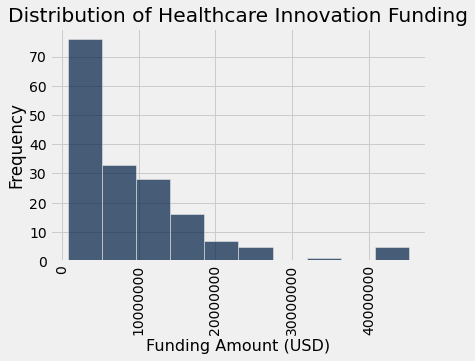

In [ ]:
# Creating a histogram to visualize the distribution of funding amounts
data.hist("Funding Clean", density=False)
# Adding title and axis labels for clarity
plots.title("Distribution of Healthcare Innovation Funding")
plots.xlabel("Funding Amount (USD)")
plots.ylabel("Frequency")

This concentration of funding suggests that decision-makers may prioritize a smaller number of high-impact initiatives, rather than distributing resources evenly across all projects.

## Secondary Analysis
The scatter plot illustrates the relationship between funding amounts and projected savings for healthcare innovation projects. Overall, there appears to be a positive relationship, as projects with higher funding levels tend to have higher projected savings.

However, the data points are widely dispersed, indicating that this relationship is not consistent across all projects. Some initiatives receive significant funding but do not correspond to proportionally higher projected savings, while others achieve relatively high savings with lower investment levels.

This variability suggests that while increased funding can contribute to greater expected impact, the efficiency of investment varies across projects. As a result, factors beyond funding level likely play an important role in determining the success and effectiveness of healthcare innovation initiatives.

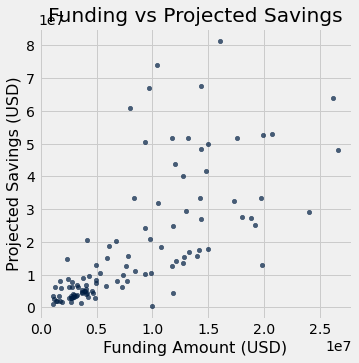

In [ ]:
# Creating a scatter plot to examine the relationship between funding and projected savings
data.scatter("Funding Clean", "Savings Clean")

# Adding titles and axis labels for clarity
plots.title("Funding vs Projected Savings")
plots.xlabel("Funding Amount (USD)")
plots.ylabel("Projected Savings (USD)")

This suggests that simply increasing funding may not guarantee improved outcomes, highlighting the importance of how resources are allocated and managed.

## Stakeholders
One key stakeholder group is policymakers, such as those at the Centers for Medicare & Medicaid Services (CMS). These stakeholders are responsible for allocating funding and designing healthcare innovation programs. From this analysis, they can learn that funding is concentrated among a smaller number of high-investment projects and that higher funding does not always result in proportionally higher projected savings. This suggests a need to evaluate not only how much funding is allocated, but also how effectively it is used. Policymakers should consider incorporating additional evaluation criteria beyond funding size to ensure investments are directed toward the most impactful initiatives.

A second stakeholder group is healthcare and biopharmaceutical companies, including organizations such as Pfizer, Johnson & Johnson, AstraZeneca, and Exact Sciences. While these companies are not directly represented in the dataset, they operate within the broader healthcare ecosystem and are influenced by trends in healthcare innovation and funding priorities. Insights from this analysis can help these organizations understand how healthcare systems prioritize investment in innovation and cost efficiency. In response, these companies should focus on aligning their strategies with initiatives that demonstrate strong value and measurable impact, as funding alone does not guarantee successful outcomes.

## Conclusion
This analysis shows that healthcare innovation funding is unevenly distributed and that higher funding levels do not consistently result in greater projected savings. While there is a general positive relationship between funding and outcomes, the variability suggests that other factors play a significant role in determining success.

These findings highlight the importance of strategic decision-making in healthcare investment. Improving how funding is allocated and ensuring efficient implementation of innovation initiatives will be critical for achieving meaningful improvements in healthcare systems.